In [1]:
# Bayesian Optimization mit Nullmodellen pro Sequenz
# Sucht nach der besten Parameterkombination für die Proximity-Funktion
# unter Verwendung von Bayesian Optimization.

# ================================
# Imports
# ================================
import os
import numpy as np
import pandas as pd
from skopt import gp_minimize
from skopt.space import Real, Integer
import matplotlib.pyplot as plt
import seaborn as sns

# ================================
# Proximity-Funktion
# ================================
def proximity_max_freq(
    x,
    sharpness_base=10.0,
    sharpness_growth=2.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    norm_x=1.0,
    output_max=1.0
):
    x = np.array(x)
    freqs = np.arange(1, max_freq + 1)
    all_freq_values = []

    for freq in freqs:
        weight = 1.0 / (freq ** weight_exponent)
        freq_sharpness_base = sharpness_base * (freq ** freq_sharpness_exp)
        freq_sharpness_growth = sharpness_growth * (freq ** freq_sharpness_exp)

        sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)
        cos_term = ((1 + np.cos(2 * np.pi * freq * x)) / 2) ** sharpness

        peak_sharpness = freq_sharpness_base * (norm_x ** freq_sharpness_growth)
        peak_value = ((1 + np.cos(2 * np.pi * freq * norm_x)) / 2) ** peak_sharpness
        peak_value = np.where(peak_value == 0, 1e-12, peak_value)

        denom = np.where(x == 0, 1e-12, x ** decay)
        val = weight * (cos_term / peak_value) / denom
        all_freq_values.append(val)

    all_freq_values = np.array(all_freq_values)
    proximity_max = np.max(all_freq_values, axis=0)

    max_at_norm_x = np.max([
        (1.0 / (freq ** weight_exponent)) * 1.0 / (norm_x ** decay)
        for freq in freqs
    ])
    proximity_max = proximity_max / max_at_norm_x * output_max
    return proximity_max

# ================================
# Folder-Analyse
# ================================
def analyze_folder(folder_path, params, num_sequences=500, seed=42):
    rng = np.random.default_rng(seed)
    results_list = []

    for fname in os.listdir(folder_path):
        if not fname.endswith(".csv"):
            continue

        df = pd.read_csv(os.path.join(folder_path, fname))
        if "IOI" not in df.columns:
            continue

        iois = df["IOI"].dropna().values
        if len(iois) < 3:
            continue

        sequence_length = len(iois)
        max_ioi = float(np.max(iois))
        mean_ioi = float(np.mean(iois))

        # Real sequence
        ratios_real = np.array([[max(iois[i], iois[j]) / min(iois[i], iois[j])
                                 for j in range(sequence_length)] for i in range(sequence_length)])
        prox_mat_real = proximity_max_freq(ratios_real, **params)
        triu_idx = np.triu_indices_from(prox_mat_real, k=1)
        proximity_real = prox_mat_real[triu_idx]
        median_real = np.median(proximity_real)

        # Exponential null
        medians_expon = []
        for _ in range(num_sequences):
            pois_iois = rng.exponential(scale=mean_ioi, size=sequence_length)
            ratios = np.array([[max(pois_iois[i], pois_iois[j]) / min(pois_iois[i], pois_iois[j])
                                for j in range(sequence_length)] for i in range(sequence_length)])
            prox_mat = proximity_max_freq(ratios, **params)
            medians_expon.append(np.median(prox_mat[triu_idx]))
        medians_expon = np.array(medians_expon)
        mean_expon = np.mean(medians_expon)
        std_expon = np.std(medians_expon, ddof=1)
        zscore_expon = (median_real - mean_expon) / std_expon if std_expon > 0 else np.nan
        pval_expon = (np.sum(medians_expon >= median_real) + 1) / (num_sequences + 1)

        # Uniform null
        medians_uniform = []
        for _ in range(num_sequences):
            unif_iois = rng.uniform(0.01, max_ioi, size=sequence_length)
            ratios = np.array([[max(unif_iois[i], unif_iois[j]) / min(unif_iois[i], unif_iois[j])
                                for j in range(sequence_length)] for i in range(sequence_length)])
            prox_mat = proximity_max_freq(ratios, **params)
            medians_uniform.append(np.median(prox_mat[triu_idx]))
        medians_uniform = np.array(medians_uniform)
        mean_uniform = np.mean(medians_uniform)
        std_uniform = np.std(medians_uniform, ddof=1)
        zscore_uniform = (median_real - mean_uniform) / std_uniform if std_uniform > 0 else np.nan
        pval_uniform = (np.sum(medians_uniform >= median_real) + 1) / (num_sequences + 1)

        results_list.append({
            "filename": fname,
            "real_median": median_real,
            "expon_mean": mean_expon,
            "expon_std": std_expon,
            "uniform_mean": mean_uniform,
            "uniform_std": std_uniform,
            "diff_real_expon": median_real - mean_expon,
            "diff_real_uniform": median_real - mean_uniform,
            "zscore_expon": zscore_expon,
            "pval_expon": pval_expon,
            "zscore_uniform": zscore_uniform,
            "pval_uniform": pval_uniform,
        })

    return pd.DataFrame(results_list)

# ================================
# Bayesian Optimization
# ================================

def bayesian_search(
    folder_path,
    n_calls=100,
    num_sequences=500,
    seed=42,
    objective="zscore",   # one of: "diff", "zscore", "pval"
    null_model="expon",   # name used in analyze_folder columns: "expon", "uniform", "kde", "gamma", ...
    param_space_def=None   # optional: override default param space dictionary (same keys as before)
):
    """
    Bayesian search over the proximity-function parameter space.
    objective: "diff" (max), "zscore" (max), "pval" (min)
    null_model: string used to select columns returned by analyze_folder, e.g. "expon" -> diff_real_expon, zscore_expon, pval_expon
    Returns: summary_df (all evaluated params saved), best_params (according to chosen objective)
    """

    rng = np.random.default_rng(seed)
    default_params = {"norm_x": 1.0, "output_max": 1.0}

    # default parameter-space (same ranges as before)
    if param_space_def is None:
        param_space_def = {
            "sharpness_base": (1.0, 50.0),
            "sharpness_growth": (0.0, 5.0),
            "decay": (0.0, 4.0),
            "max_freq": (1, 6),  # integer
            "weight_exponent": (0.0, 4.0),
            "freq_sharpness_exp": (0.0, 4.0)
        }

    # build skopt space
    sk_space = [
        Real(param_space_def["sharpness_base"][0], param_space_def["sharpness_base"][1], name="sharpness_base"),
        Real(param_space_def["sharpness_growth"][0], param_space_def["sharpness_growth"][1], name="sharpness_growth"),
        Real(param_space_def["decay"][0], param_space_def["decay"][1], name="decay"),
        Integer(param_space_def["max_freq"][0], param_space_def["max_freq"][1], name="max_freq"),
        Real(param_space_def["weight_exponent"][0], param_space_def["weight_exponent"][1], name="weight_exponent"),
        Real(param_space_def["freq_sharpness_exp"][0], param_space_def["freq_sharpness_exp"][1], name="freq_sharpness_exp"),
    ]

    # will store intermediate results for post-hoc analysis
    eval_records = []

    # objective function for gp_minimize (we minimize)
    def objective_func(x):
        # map x to param dict
        names = ["sharpness_base", "sharpness_growth", "decay", "max_freq", "weight_exponent", "freq_sharpness_exp"]
        params = default_params.copy()
        params.update({n: v for n, v in zip(names, x)})
        # cast max_freq to int if it's Real (skopt Integer should handle it but ensure)
        params["max_freq"] = int(round(params["max_freq"]))

        # run analysis (this is the expensive call)
        results_df = analyze_folder(folder_path, params, num_sequences=num_sequences, seed=seed)

        # if nothing returned, give a neutral objective
        if results_df.empty:
            # return a large positive value so optimizer avoids this region
            return 1e6

        # choose metric column names depending on null_model & objective
        col_map = {
            "diff": f"diff_real_{null_model}",
            "zscore": f"zscore_{null_model}",
            "pval": f"pval_{null_model}"
        }
        if objective not in col_map:
            raise ValueError("objective must be one of: 'diff','zscore','pval'")

        col = col_map[objective]
        if col not in results_df.columns:
            # if the requested null-model/metric is not available, return bad value
            return 1e5

        # for robustness use median across files
        vals = results_df[col].dropna().values
        if len(vals) == 0:
            return 1e5

        # metric aggregation:
        # - for diff and zscore we want to maximize -> return negative median (since gp_minimize minimizes)
        # - for pval we want to minimize -> return median pval
        if objective in ("diff", "zscore"):
            agg = np.median(vals)
            score = -float(agg)
        else:  # pval
            agg = np.median(vals)
            score = float(agg)

        # record for later inspection
        eval_records.append({**params, f"agg_{objective}_{null_model}": float(agg)})

        return score

    # run Bayesian optimization
    res = gp_minimize(objective_func, sk_space, n_calls=n_calls, random_state=seed)

    # collect evaluated params into DataFrame
    summary_eval_df = pd.DataFrame(eval_records)

    # determine best set according to chosen objective
    agg_col_name = f"agg_{objective}_{null_model}"
    if agg_col_name in summary_eval_df.columns and not summary_eval_df.empty:
        if objective in ("diff", "zscore"):
            best_idx = summary_eval_df[agg_col_name].idxmax()
        else:  # pval
            best_idx = summary_eval_df[agg_col_name].idxmin()
        best_row = summary_eval_df.loc[best_idx]
    else:
        best_row = None

    return summary_eval_df, best_row, res

# ================================
# Aufruf der Bayesian Search mit Parameter-Logging
# ================================

# Warnungen für Überlauf (overflow) ignorieren
np.seterr(over='ignore', divide='warn', invalid='warn')

folder_path = "/Users/emilschmiedl/Desktop/Proximity-Funktion/testing for bayesian"

# Parameter für bayesian_search
n_calls = 50
num_sequences = 500
seed = 42
objective = "zscore"   # "diff", "zscore" oder "pval"
null_model = "expon"   # Nullmodell
param_space_def = None  # optional

# Parameter ausgeben
print("=== Bayesian Search Konfiguration ===")
print(f"Folder path: {folder_path}")
print(f"n_calls: {n_calls}")
print(f"num_sequences: {num_sequences}")
print(f"seed: {seed}")
print(f"objective: {objective}")
print(f"null_model: {null_model}")
print("=====================================")

# ================================
# Bayesian Search ausführen
# ================================
summary_eval_df, best_row, res = bayesian_search(
    folder_path=folder_path,
    n_calls=n_calls,
    num_sequences=num_sequences,
    seed=seed,
    objective=objective,
    null_model=null_model,
    param_space_def=param_space_def
)

# Ergebnisse in DataFrame
results_df = summary_eval_df.copy()

# Top 10 Ergebnisse nach Zielwert
print("\nTop 10 Ergebnisse der Bayesian Optimization:")
print(results_df.sort_values(by=results_df.columns[-1], ascending=False).head(10))

# Verlauf der Zielwerte über Iterationen
plt.figure(figsize=(10, 5))
plt.plot(results_df[results_df.columns[-1]].values, marker='o')
plt.title(f'Verlauf der Zielwerte über Iterationen\nObjective = {objective}, Null-Modell = {null_model}')
plt.xlabel('Iteration')
plt.ylabel(f'Zielwert ({objective}_{null_model})')
plt.grid(True)
plt.show()

# Histogramm der Zielwerte
plt.figure(figsize=(8, 4))
sns.histplot(results_df[results_df.columns[-1]], bins=15, kde=True)
plt.title(f'Verteilung der Zielwerte\nObjective = {objective}, Null-Modell = {null_model}')
plt.xlabel(f'Zielwert ({objective}_{null_model})')
plt.ylabel('Häufigkeit')
plt.show()

# Pairplot für Parameter vs. Zielwert
param_cols = ["sharpness_base","sharpness_growth","decay","max_freq","weight_exponent","freq_sharpness_exp"]

if len(param_cols) <= 6:
    sns.pairplot(
        results_df,
        vars=param_cols,
        hue=results_df.columns[-1],
        palette='viridis',
        height=2.5,
        diag_kind="hist"
    )
    plt.suptitle(f'Parameter-Paarungen vs Zielwert\nObjective = {objective}, Null-Modell = {null_model}', y=1.02)
    plt.show()

# Beste Parameterkombination
print("\nBeste Parameterkombination:")
print(best_row[param_cols])

# Optional: Export als CSV mit Parametern im Dateinamen
filename = f"bayesian_search_results_{objective}_{null_model}_n{n_calls}_seq{num_sequences}_seed{seed}.csv"
results_df.to_csv(filename, index=False)
print(f"Ergebnisse wurden als '{filename}' gespeichert.")


=== Bayesian Search Konfiguration ===
Folder path: /Users/emilschmiedl/Desktop/Proximity-Funktion/testing for bayesian
n_calls: 50
num_sequences: 500
seed: 42
objective: zscore
null_model: expon


KeyboardInterrupt: 

=== Bayesian Search Konfiguration ===
Folder path: /Users/emilschmiedl/Desktop/Proximity-Funktion/testing for bayesian
n_calls: 80
num_sequences: 700
seed: 42
objective: diff
null_model: expon
Global median IOI = 0.750
Uniform bounds = [0.422, 1.062]

Top 10 Ergebnisse der Bayesian Optimization:
    norm_x  output_max  sharpness_base  sharpness_growth  decay  max_freq  \
72     1.0         1.0             1.0          1.498051    0.0         1   
22     1.0         1.0             1.0          1.513585    0.0         1   
29     1.0         1.0             1.0          1.499269    0.0         2   
57     1.0         1.0             1.0          1.508506    0.0         6   
79     1.0         1.0             1.0          1.535304    0.0         5   
58     1.0         1.0             1.0          1.549176    0.0         6   
41     1.0         1.0             1.0          1.571403    0.0         1   
50     1.0         1.0             1.0          1.571562    0.0         1   
46     1.0

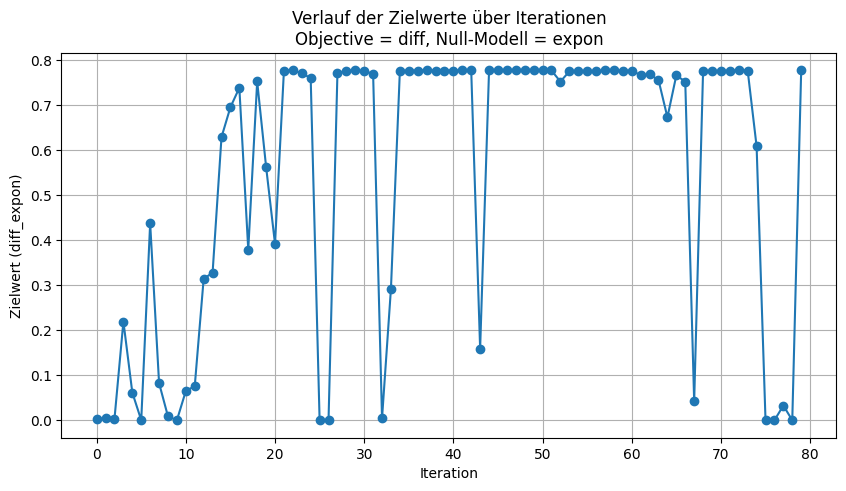

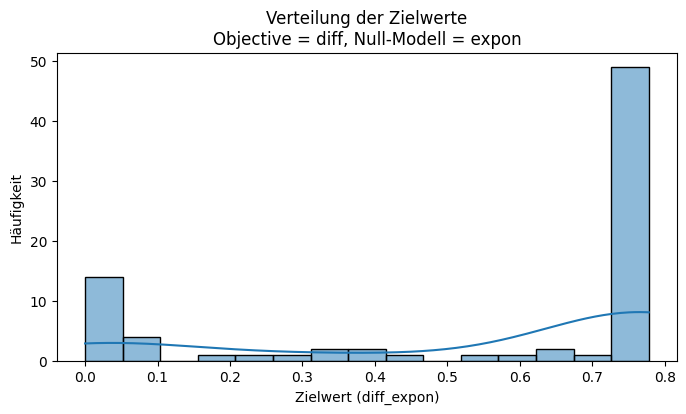

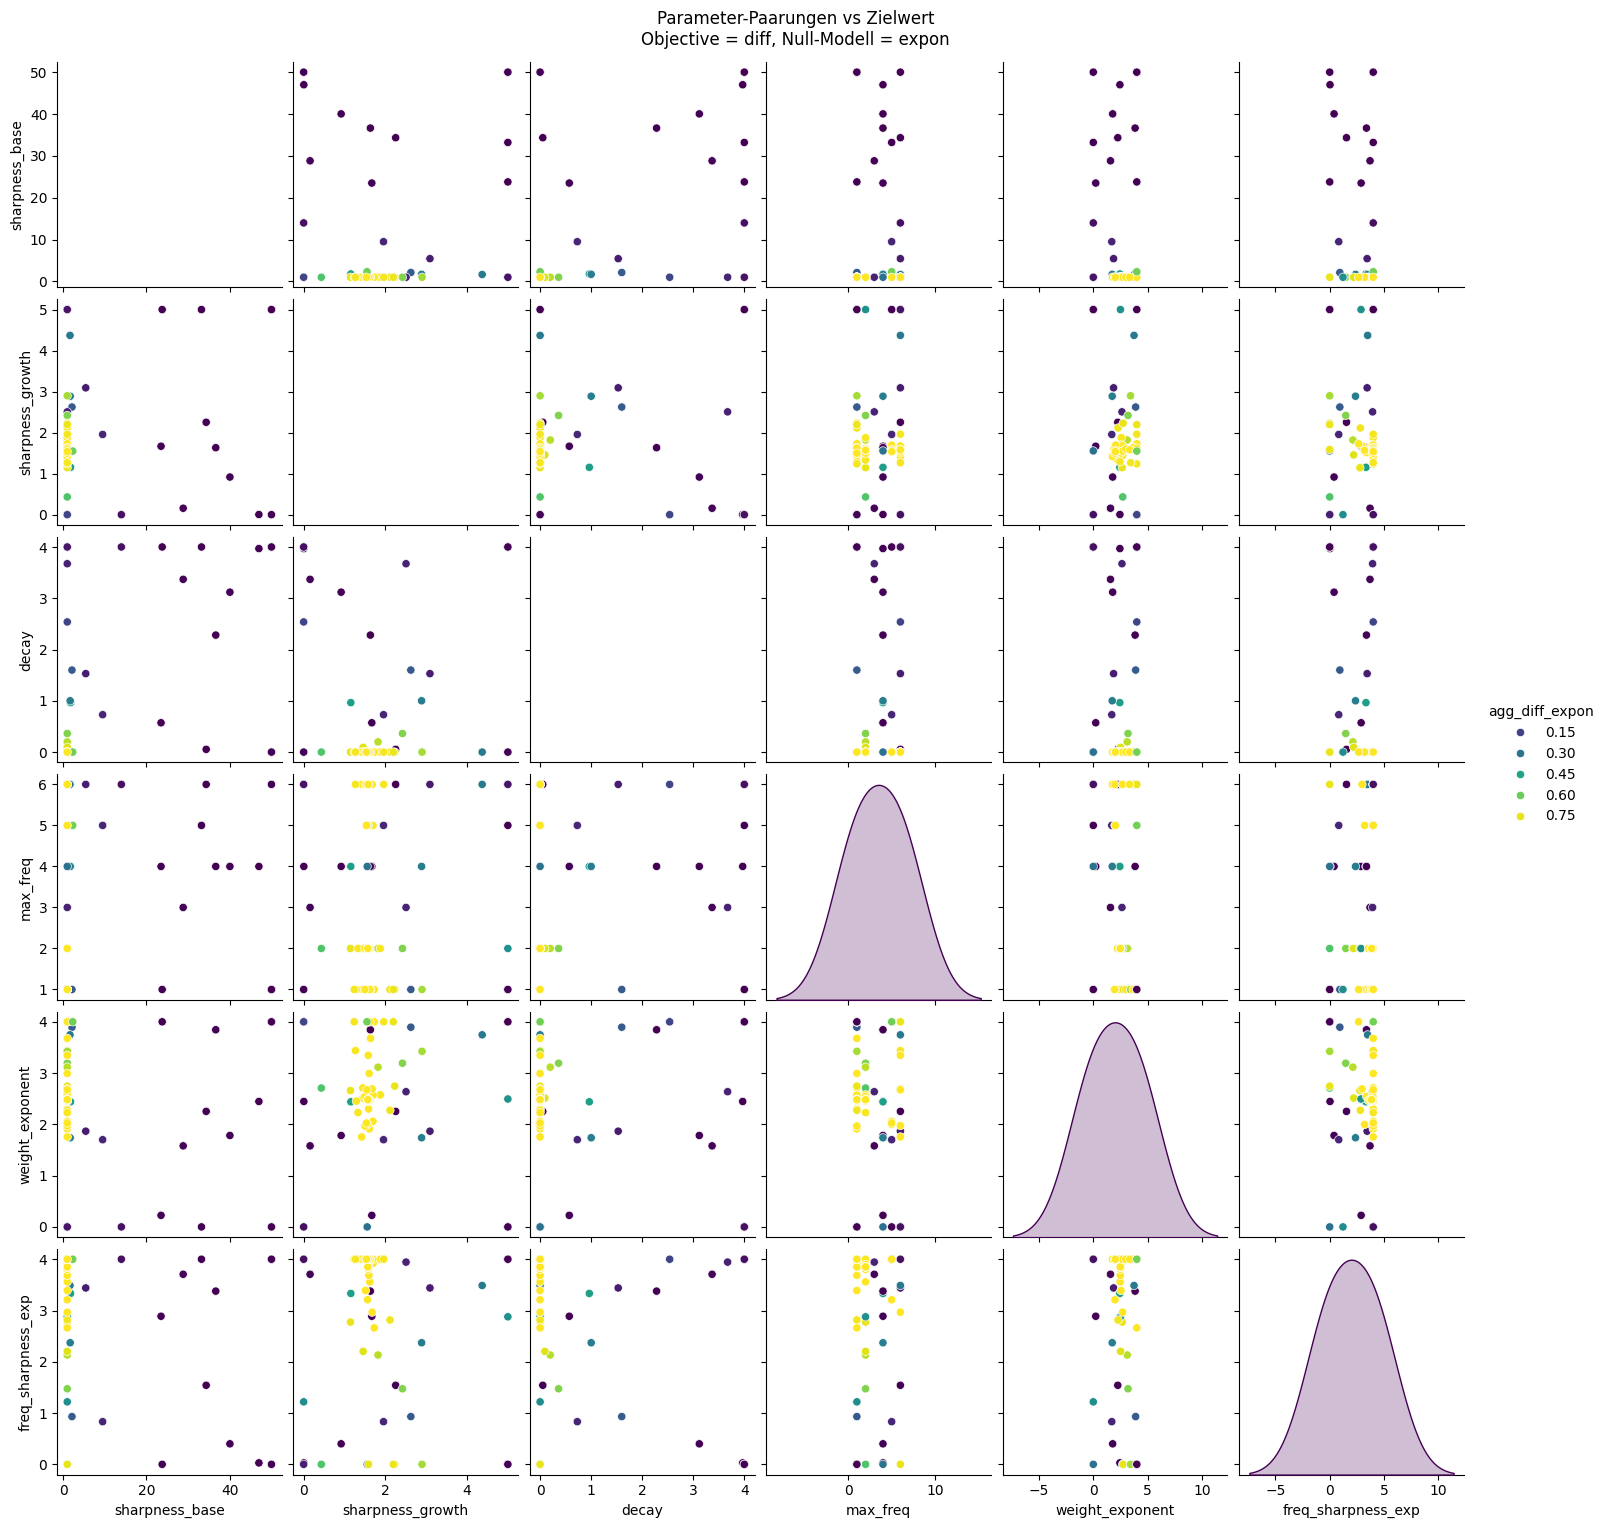


Beste Parameterkombination:
sharpness_base        1.000000
sharpness_growth      1.498051
decay                 0.000000
max_freq              1.000000
weight_exponent       1.967722
freq_sharpness_exp    4.000000
Name: 72, dtype: float64
Ergebnisse wurden als 'bayesian_search_results_diff_expon_n80_seq700_seed42.csv' gespeichert.


In [ ]:
# Bayesian Optimization mit globalen Nullmodellen aus Ordner
# Sucht nach der besten Parameterkombination für die Proximity-Funktion
# unter Verwendung von Bayesian Optimization.

# ================================
# Imports
# ================================
import os
import numpy as np
import pandas as pd
from skopt import gp_minimize
from skopt.space import Real, Integer
import matplotlib.pyplot as plt
import seaborn as sns

# ================================
# Proximity-Funktion
# ================================

def proximity_max_freq(
    x,
    sharpness_base=10.0,
    sharpness_growth=2.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    norm_x=1.0,
    output_max=1.0
):
    x = np.array(x)
    freqs = np.arange(1, max_freq + 1)
    all_freq_values = []

    for freq in freqs:
        weight = 1.0 / (freq ** weight_exponent)
        freq_sharpness_base = sharpness_base * (freq ** freq_sharpness_exp)
        freq_sharpness_growth = sharpness_growth * (freq ** freq_sharpness_exp)

        sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)
        cos_term = ((1 + np.cos(2 * np.pi * freq * x)) / 2) ** sharpness

        peak_sharpness = freq_sharpness_base * (norm_x ** freq_sharpness_growth)
        peak_value = ((1 + np.cos(2 * np.pi * freq * norm_x)) / 2) ** peak_sharpness
        peak_value = np.where(peak_value == 0, 1e-12, peak_value)

        denom = np.where(x == 0, 1e-12, x ** decay)
        val = weight * (cos_term / peak_value) / denom
        all_freq_values.append(val)

    all_freq_values = np.array(all_freq_values)
    proximity_max = np.max(all_freq_values, axis=0)

    max_at_norm_x = np.max([
        (1.0 / (freq ** weight_exponent)) * 1.0 / (norm_x ** decay)
        for freq in freqs
    ])
    proximity_max = proximity_max / max_at_norm_x * output_max
    return proximity_max

# ================================
# Folder-Analyse
# ================================
_already_printed_global_ioi = False

def analyze_folder_global_null(folder_path, params, num_sequences=500, seed=42):
    global _already_printed_global_ioi
    rng = np.random.default_rng(seed)
    results_list = []

    # -----------------------------
    # 1) Alle IOIs laden und globale Parameter bestimmen
    # -----------------------------
    all_iois = []
    seqs = []

    for fname in os.listdir(folder_path):
        if not fname.endswith(".csv"):
            continue

        df = pd.read_csv(os.path.join(folder_path, fname))
        if "IOI" not in df.columns:
            continue

        iois = df["IOI"].dropna().values
        if len(iois) < 3:
            continue

        all_iois.extend(iois)
        seqs.append((fname, iois))

    all_iois = np.array(all_iois)
    global_median_ioi = np.median(all_iois)
    global_min = np.percentile(all_iois, 5)
    global_max = np.percentile(all_iois, 95)

    # nur beim allerersten Funktionsaufruf ausgeben
    if not _already_printed_global_ioi:
        print(f"Global median IOI = {global_median_ioi:.3f}")
        print(f"Uniform bounds = [{global_min:.3f}, {global_max:.3f}]")
        _already_printed_global_ioi = True
    
    # -----------------------------
    # 2) Nullmodelle vorbereiten (pro Sequenz-Länge!)
    # -----------------------------
    null_cache_expon = {}
    null_cache_uniform = {}

    for fname, iois in seqs:
        n = len(iois)

        # Exponential Null
        if n not in null_cache_expon:
            medians_expon = []
            for _ in range(num_sequences):
                sim_iois = rng.exponential(scale=global_median_ioi, size=n)
                ratios = np.array([[max(sim_iois[i], sim_iois[j]) / min(sim_iois[i], sim_iois[j])
                                    for j in range(n)] for i in range(n)])
                prox_mat = proximity_max_freq(ratios, **params)
                triu_idx = np.triu_indices_from(prox_mat, k=1)
                medians_expon.append(np.median(prox_mat[triu_idx]))
            null_cache_expon[n] = np.array(medians_expon)

        # Uniform Null
        if n not in null_cache_uniform:
            medians_uniform = []
            for _ in range(num_sequences):
                sim_iois = rng.uniform(global_min, global_max, size=n)
                ratios = np.array([[max(sim_iois[i], sim_iois[j]) / min(sim_iois[i], sim_iois[j])
                                    for j in range(n)] for i in range(n)])
                prox_mat = proximity_max_freq(ratios, **params)
                triu_idx = np.triu_indices_from(prox_mat, k=1)
                medians_uniform.append(np.median(prox_mat[triu_idx]))
            null_cache_uniform[n] = np.array(medians_uniform)

    # -----------------------------
    # 3) Analyse jeder Sequenz mit den globalen Nullmodellen
    # -----------------------------
    for fname, iois in seqs:
        n = len(iois)
        ratios_real = np.array([[max(iois[i], iois[j]) / min(iois[i], iois[j])
                                 for j in range(n)] for i in range(n)])
        prox_mat_real = proximity_max_freq(ratios_real, **params)
        triu_idx = np.triu_indices_from(prox_mat_real, k=1)
        proximity_real = prox_mat_real[triu_idx]
        median_real = np.median(proximity_real)

        # Exponential
        medians_expon = null_cache_expon[n]
        mean_expon = np.mean(medians_expon)
        std_expon = np.std(medians_expon, ddof=1)
        zscore_expon = (median_real - mean_expon) / std_expon if std_expon > 0 else np.nan
        pval_expon = (np.sum(medians_expon >= median_real) + 1) / (len(medians_expon) + 1)

        # Uniform
        medians_uniform = null_cache_uniform[n]
        mean_uniform = np.mean(medians_uniform)
        std_uniform = np.std(medians_uniform, ddof=1)
        zscore_uniform = (median_real - mean_uniform) / std_uniform if std_uniform > 0 else np.nan
        pval_uniform = (np.sum(medians_uniform >= median_real) + 1) / (len(medians_uniform) + 1)

        results_list.append({
            "filename": fname,
            "real_median": median_real,
            "expon_mean": mean_expon,
            "expon_std": std_expon,
            "uniform_mean": mean_uniform,
            "uniform_std": std_uniform,
            "diff_real_expon": median_real - mean_expon,
            "diff_real_uniform": median_real - mean_uniform,
            "zscore_expon": zscore_expon,
            "pval_expon": pval_expon,
            "zscore_uniform": zscore_uniform,
            "pval_uniform": pval_uniform,
        })

    return pd.DataFrame(results_list)

# ================================
# Bayesian Optimization
# ================================

def bayesian_search_global_null(
    folder_path,
    n_calls=100,
    num_sequences=500,
    seed=42,
    objective="zscore",   # one of: "diff", "zscore", "pval"
    null_model="expon",   # name used in analyze_folder columns for now: "expon", "uniform" ...
    param_space_def=None   # optional: override default param space dictionary (same keys as before)
):
    """
    Bayesian search over the proximity-function parameter space.
    objective: "diff" (max), "zscore" (max), "pval" (min)
    null_model: string used to select columns returned by analyze_folder, e.g. "expon" -> diff_real_expon, zscore_expon, pval_expon
    Returns: summary_df (all evaluated params saved), best_params (according to chosen objective)
    """

    rng = np.random.default_rng(seed)
    default_params = {"norm_x": 1.0, "output_max": 1.0}

    # default parameter-space (same ranges as before)
    if param_space_def is None:
        param_space_def = {
            "sharpness_base": (1.0, 50.0),
            "sharpness_growth": (0.0, 5.0),
            "decay": (0.0, 4.0),
            "max_freq": (1, 6),  # integer
            "weight_exponent": (0.0, 4.0),
            "freq_sharpness_exp": (0.0, 4.0)
        }

    # build skopt space
    sk_space = [
        Real(param_space_def["sharpness_base"][0], param_space_def["sharpness_base"][1], name="sharpness_base"),
        Real(param_space_def["sharpness_growth"][0], param_space_def["sharpness_growth"][1], name="sharpness_growth"),
        Real(param_space_def["decay"][0], param_space_def["decay"][1], name="decay"),
        Integer(param_space_def["max_freq"][0], param_space_def["max_freq"][1], name="max_freq"),
        Real(param_space_def["weight_exponent"][0], param_space_def["weight_exponent"][1], name="weight_exponent"),
        Real(param_space_def["freq_sharpness_exp"][0], param_space_def["freq_sharpness_exp"][1], name="freq_sharpness_exp"),
    ]

    # will store intermediate results for post-hoc analysis
    eval_records = []

    # objective function for gp_minimize (we minimize)
    def objective_func(x):
        # map x to param dict
        names = ["sharpness_base", "sharpness_growth", "decay", "max_freq", "weight_exponent", "freq_sharpness_exp"]
        params = default_params.copy()
        params.update({n: v for n, v in zip(names, x)})
        # cast max_freq to int if it's Real (skopt Integer should handle it but ensure)
        params["max_freq"] = int(round(params["max_freq"]))

        # run analysis (this is the expensive call)
        results_df = analyze_folder_global_null(folder_path, params, num_sequences=num_sequences, seed=seed)

        # if nothing returned, give a neutral objective
        if results_df.empty:
            # return a large positive value so optimizer avoids this region
            return 1e6

        # choose metric column names depending on null_model & objective
        col_map = {
            "diff": f"diff_real_{null_model}",
            "zscore": f"zscore_{null_model}",
            "pval": f"pval_{null_model}"
        }
        if objective not in col_map:
            raise ValueError("objective must be one of: 'diff','zscore','pval'")

        col = col_map[objective]
        if col not in results_df.columns:
            # if the requested null-model/metric is not available, return bad value
            return 1e5

        # for robustness use median across files
        vals = results_df[col].dropna().values
        if len(vals) == 0:
            return 1e5

        # metric aggregation:
        # - for diff and zscore we want to maximize -> return negative median (since gp_minimize minimizes)
        # - for pval we want to minimize -> return median pval
        if objective in ("diff", "zscore"):
            agg = np.median(vals)
            score = -float(agg)
        else:  # pval
            agg = np.median(vals)
            score = float(agg)

        # record for later inspection
        eval_records.append({**params, f"agg_{objective}_{null_model}": float(agg)})

        return score

    # run Bayesian optimization
    res = gp_minimize(objective_func, sk_space, n_calls=n_calls, random_state=seed)

    # collect evaluated params into DataFrame
    summary_eval_df = pd.DataFrame(eval_records)

    # determine best set according to chosen objective
    agg_col_name = f"agg_{objective}_{null_model}"
    if agg_col_name in summary_eval_df.columns and not summary_eval_df.empty:
        if objective in ("diff", "zscore"):
            best_idx = summary_eval_df[agg_col_name].idxmax()
        else:  # pval
            best_idx = summary_eval_df[agg_col_name].idxmin()
        best_row = summary_eval_df.loc[best_idx]
    else:
        best_row = None

    return summary_eval_df, best_row, res

# ================================
# Aufruf der Bayesian Search mit Parameter-Logging
# ================================

# Warnungen für Überlauf (overflow) ignorieren
np.seterr(over='ignore', divide='warn', invalid='warn')

folder_path = "/Users/emilschmiedl/Desktop/Proximity-Funktion/testing for bayesian"

# Parameter für bayesian_search_global_null
n_calls = 80
num_sequences = 700
seed = 42
objective = "diff"   # Ziele: "diff", "zscore" oder "pval"
null_model = "expon"   # Nullmodelle: "expon", "uniform"
param_space_def = None  # optional

# Parameter ausgeben
print("=== Bayesian Search Konfiguration ===")
print(f"Folder path: {folder_path}")
print(f"n_calls: {n_calls}")
print(f"num_sequences: {num_sequences}")
print(f"seed: {seed}")
print(f"objective: {objective}")
print(f"null_model: {null_model}")
print("=====================================")

# ================================
# Bayesian Search ausführen
# ================================
summary_eval_df, best_row, res = bayesian_search_global_null(
    folder_path=folder_path,
    n_calls=n_calls,
    num_sequences=num_sequences,
    seed=seed,
    objective=objective,
    null_model=null_model,
    param_space_def=param_space_def
)

# Ergebnisse in DataFrame
results_df = summary_eval_df.copy()

# Top 10 Ergebnisse nach Zielwert
print("\nTop 10 Ergebnisse der Bayesian Optimization:")
print(results_df.sort_values(by=results_df.columns[-1], ascending=False).head(10))

# Verlauf der Zielwerte über Iterationen
plt.figure(figsize=(10, 5))
plt.plot(results_df[results_df.columns[-1]].values, marker='o')
plt.title(f'Verlauf der Zielwerte über Iterationen\nObjective = {objective}, Null-Modell = {null_model}')
plt.xlabel('Iteration')
plt.ylabel(f'Zielwert ({objective}_{null_model})')
plt.grid(True)
plt.show()

# Histogramm der Zielwerte
plt.figure(figsize=(8, 4))
sns.histplot(results_df[results_df.columns[-1]], bins=15, kde=True)
plt.title(f'Verteilung der Zielwerte\nObjective = {objective}, Null-Modell = {null_model}')
plt.xlabel(f'Zielwert ({objective}_{null_model})')
plt.ylabel('Häufigkeit')
plt.show()

# Pairplot für Parameter vs. Zielwert
param_cols = ["sharpness_base","sharpness_growth","decay","max_freq","weight_exponent","freq_sharpness_exp"]

if len(param_cols) <= 6:
    sns.pairplot(
        results_df,
        vars=param_cols,
        hue=results_df.columns[-1],
        palette='viridis',
        height=2.5
    )
    plt.suptitle(f'Parameter-Paarungen vs Zielwert\nObjective = {objective}, Null-Modell = {null_model}', y=1.02)
    plt.show()

# Beste Parameterkombination
print("\nBeste Parameterkombination:")
print(best_row[param_cols])

# Optional: Export als CSV mit Parametern im Dateinamen
filename = f"bayesian_search_results_{objective}_{null_model}_n{n_calls}_seq{num_sequences}_seed{seed}.csv"
results_df.to_csv(filename, index=False)
print(f"Ergebnisse wurden als '{filename}' gespeichert.")

=== Bayesian Search Konfiguration ===
Folder path: /Users/emilschmiedl/Desktop/Proximity-Funktion/testing for bayesian
n_calls: 80
num_sequences: 700
seed: 42
objective: diff
null_model: expon
Global median IOI = 0.750
Uniform bounds = [0.422, 1.062]

Top 10 Ergebnisse der Bayesian Optimization:
    norm_x  output_max  sharpness_base  sharpness_growth  decay  max_freq  \
72     1.0         1.0             1.0          1.498051    0.0         1   
22     1.0         1.0             1.0          1.513585    0.0         1   
29     1.0         1.0             1.0          1.499269    0.0         2   
57     1.0         1.0             1.0          1.508506    0.0         6   
79     1.0         1.0             1.0          1.535304    0.0         5   
58     1.0         1.0             1.0          1.549176    0.0         6   
41     1.0         1.0             1.0          1.571403    0.0         1   
50     1.0         1.0             1.0          1.571562    0.0         1   
46     1.0

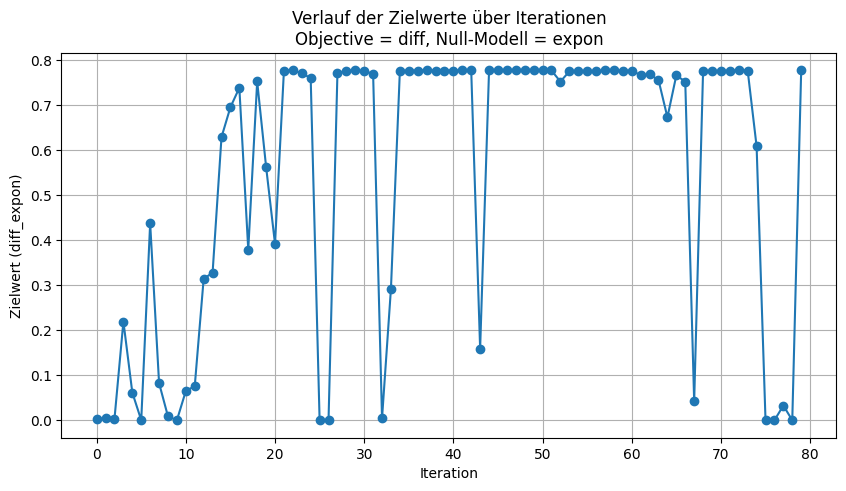

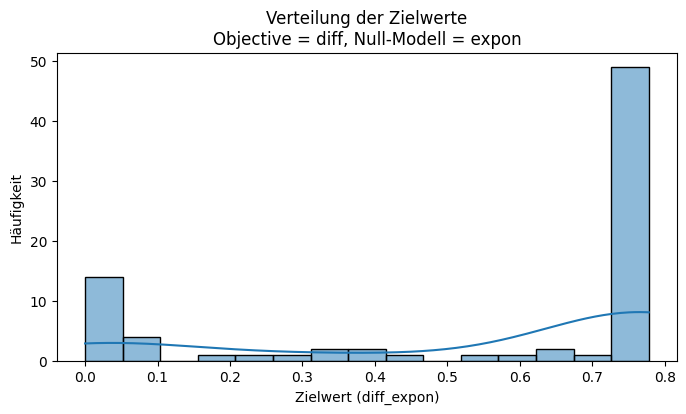

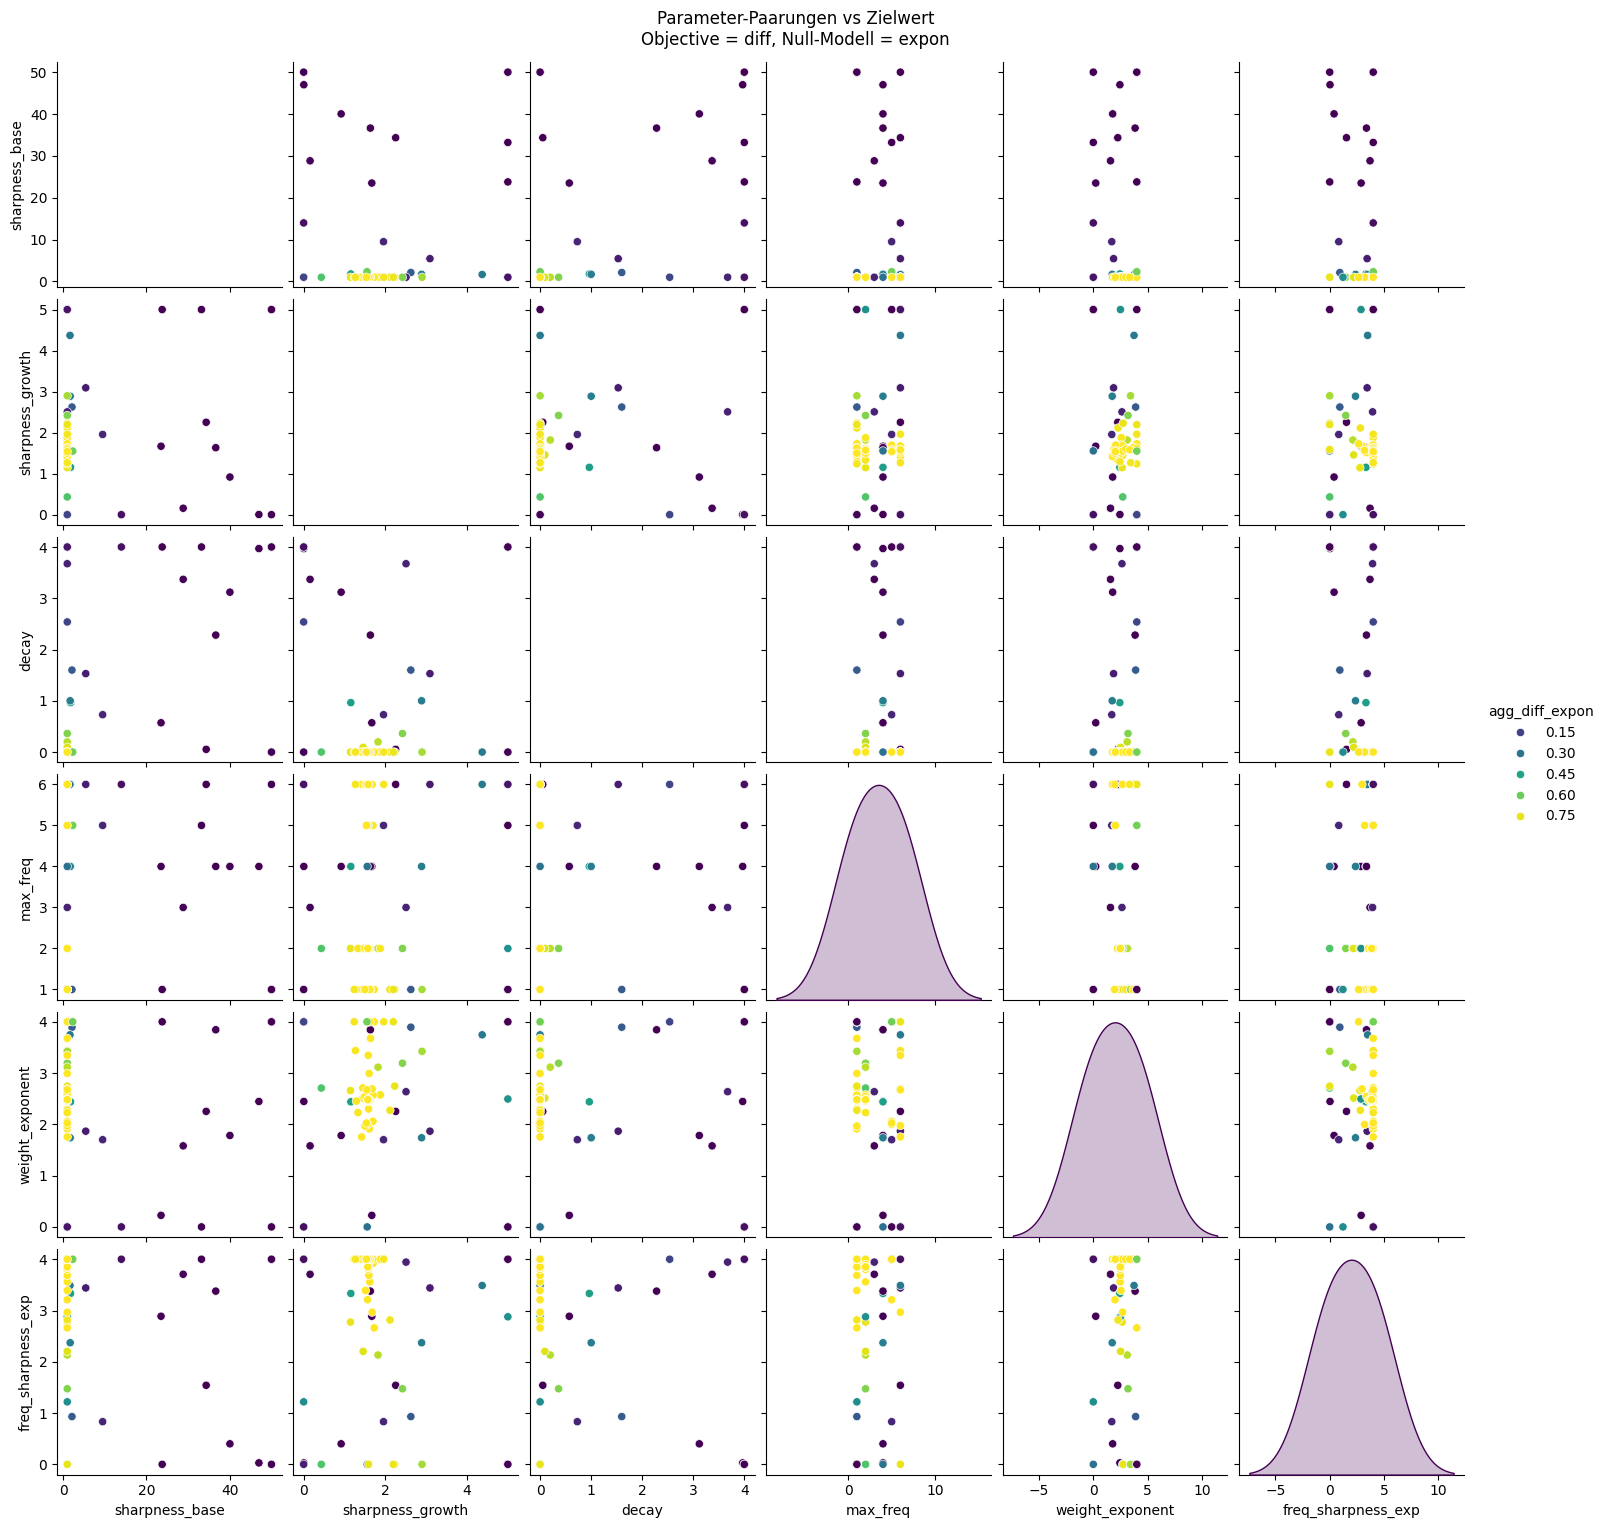


Beste Parameterkombination:
sharpness_base        1.000000
sharpness_growth      1.498051
decay                 0.000000
max_freq              1.000000
weight_exponent       1.967722
freq_sharpness_exp    4.000000
Name: 72, dtype: float64
Ergebnisse wurden als 'bayesian_search_results_diff_expon_n80_seq700_seed42.csv' gespeichert.


In [ ]:
# mit Bayesian Optimization mit globalen Nullmodellen aus Ordner
# Sucht nach der besten Parameterkombination für die Proximity-Funktion
# unter Verwendung von Bayesian Optimization.

# ================================
# Imports
# ================================
import os
import numpy as np
import pandas as pd
from skopt import gp_minimize
from skopt.space import Real, Integer
import matplotlib.pyplot as plt
import seaborn as sns

# ================================
# Proximity-Funktion
# ================================

def proximity_max_freq(
    x,
    sharpness_base=10.0,
    sharpness_growth=2.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    norm_x=1.0,
    output_max=1.0
):
    x = np.array(x)
    freqs = np.arange(1, max_freq + 1)
    all_freq_values = []

    for freq in freqs:
        weight = 1.0 / (freq ** weight_exponent)
        freq_sharpness_base = sharpness_base * (freq ** freq_sharpness_exp)
        freq_sharpness_growth = sharpness_growth * (freq ** freq_sharpness_exp)

        sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)
        cos_term = ((1 + np.cos(2 * np.pi * freq * x)) / 2) ** sharpness

        peak_sharpness = freq_sharpness_base * (norm_x ** freq_sharpness_growth)
        peak_value = ((1 + np.cos(2 * np.pi * freq * norm_x)) / 2) ** peak_sharpness
        peak_value = np.where(peak_value == 0, 1e-12, peak_value)

        denom = np.where(x == 0, 1e-12, x ** decay)
        val = weight * (cos_term / peak_value) / denom
        all_freq_values.append(val)

    all_freq_values = np.array(all_freq_values)
    proximity_max = np.max(all_freq_values, axis=0)

    max_at_norm_x = np.max([
        (1.0 / (freq ** weight_exponent)) * 1.0 / (norm_x ** decay)
        for freq in freqs
    ])
    proximity_max = proximity_max / max_at_norm_x * output_max
    return proximity_max

# ================================
# Folder-Analyse
# ================================
_already_printed_global_ioi = False

def analyze_folder_global_null(folder_path, params, num_sequences=500, seed=42):
    global _already_printed_global_ioi
    rng = np.random.default_rng(seed)
    results_list = []

    # -----------------------------
    # 1) Alle IOIs laden und globale Parameter bestimmen
    # -----------------------------
    all_iois = []
    seqs = []

    for fname in os.listdir(folder_path):
        if not fname.endswith(".csv"):
            continue

        df = pd.read_csv(os.path.join(folder_path, fname))
        if "IOI" not in df.columns:
            continue

        iois = df["IOI"].dropna().values
        if len(iois) < 3:
            continue

        all_iois.extend(iois)
        seqs.append((fname, iois))

    all_iois = np.array(all_iois)
    global_median_ioi = np.median(all_iois)
    global_min = np.percentile(all_iois, 5)
    global_max = np.percentile(all_iois, 95)

    # nur beim allerersten Funktionsaufruf ausgeben
    if not _already_printed_global_ioi:
        print(f"Global median IOI = {global_median_ioi:.3f}")
        print(f"Uniform bounds = [{global_min:.3f}, {global_max:.3f}]")
        _already_printed_global_ioi = True
    
    # -----------------------------
    # 2) Nullmodelle vorbereiten (pro Sequenz-Länge!)
    # -----------------------------
    null_cache_expon = {}
    null_cache_uniform = {}

    for fname, iois in seqs:
        n = len(iois)

        # Exponential Null
        if n not in null_cache_expon:
            medians_expon = []
            for _ in range(num_sequences):
                sim_iois = rng.exponential(scale=global_median_ioi, size=n)
                ratios = np.array([[max(sim_iois[i], sim_iois[j]) / min(sim_iois[i], sim_iois[j])
                                    for j in range(n)] for i in range(n)])
                prox_mat = proximity_max_freq(ratios, **params)
                triu_idx = np.triu_indices_from(prox_mat, k=1)
                medians_expon.append(np.median(prox_mat[triu_idx]))
            null_cache_expon[n] = np.array(medians_expon)

        # Uniform Null
        if n not in null_cache_uniform:
            medians_uniform = []
            for _ in range(num_sequences):
                sim_iois = rng.uniform(global_min, global_max, size=n)
                ratios = np.array([[max(sim_iois[i], sim_iois[j]) / min(sim_iois[i], sim_iois[j])
                                    for j in range(n)] for i in range(n)])
                prox_mat = proximity_max_freq(ratios, **params)
                triu_idx = np.triu_indices_from(prox_mat, k=1)
                medians_uniform.append(np.median(prox_mat[triu_idx]))
            null_cache_uniform[n] = np.array(medians_uniform)

    # -----------------------------
    # 3) Analyse jeder Sequenz mit den globalen Nullmodellen
    # -----------------------------
    for fname, iois in seqs:
        n = len(iois)
        ratios_real = np.array([[max(iois[i], iois[j]) / min(iois[i], iois[j])
                                 for j in range(n)] for i in range(n)])
        prox_mat_real = proximity_max_freq(ratios_real, **params)
        triu_idx = np.triu_indices_from(prox_mat_real, k=1)
        proximity_real = prox_mat_real[triu_idx]
        median_real = np.median(proximity_real)

        # Exponential
        medians_expon = null_cache_expon[n]
        mean_expon = np.mean(medians_expon)
        std_expon = np.std(medians_expon, ddof=1)
        zscore_expon = (median_real - mean_expon) / std_expon if std_expon > 0 else np.nan
        pval_expon = (np.sum(medians_expon >= median_real) + 1) / (len(medians_expon) + 1)

        # Uniform
        medians_uniform = null_cache_uniform[n]
        mean_uniform = np.mean(medians_uniform)
        std_uniform = np.std(medians_uniform, ddof=1)
        zscore_uniform = (median_real - mean_uniform) / std_uniform if std_uniform > 0 else np.nan
        pval_uniform = (np.sum(medians_uniform >= median_real) + 1) / (len(medians_uniform) + 1)

        results_list.append({
            "filename": fname,
            "real_median": median_real,
            "expon_mean": mean_expon,
            "expon_std": std_expon,
            "uniform_mean": mean_uniform,
            "uniform_std": std_uniform,
            "diff_real_expon": median_real - mean_expon,
            "diff_real_uniform": median_real - mean_uniform,
            "zscore_expon": zscore_expon,
            "pval_expon": pval_expon,
            "zscore_uniform": zscore_uniform,
            "pval_uniform": pval_uniform,
        })

    return pd.DataFrame(results_list)

# ================================
# Bayesian Optimization
# ================================

def bayesian_search_global_null(
    folder_path,
    n_calls=100,
    num_sequences=500,
    seed=42,
    objective="zscore",   # one of: "diff", "zscore", "pval"
    null_model="expon",   # name used in analyze_folder columns for now: "expon", "uniform" ...
    param_space_def=None   # optional: override default param space dictionary (same keys as before)
):
    """
    Bayesian search over the proximity-function parameter space.
    objective: "diff" (max), "zscore" (max), "pval" (min)
    null_model: string used to select columns returned by analyze_folder, e.g. "expon" -> diff_real_expon, zscore_expon, pval_expon
    Returns: summary_df (all evaluated params saved), best_params (according to chosen objective)
    """

    rng = np.random.default_rng(seed)
    default_params = {"norm_x": 1.0, "output_max": 1.0}

    # default parameter-space (same ranges as before)
    if param_space_def is None:
        param_space_def = {
            "sharpness_base": (1.0, 50.0),
            "sharpness_growth": (0.0, 5.0),
            "decay": (0.0, 4.0),
            "max_freq": (1, 6),  # integer
            "weight_exponent": (0.0, 4.0),
            "freq_sharpness_exp": (0.0, 4.0)
        }

    # build skopt space
    sk_space = [
        Real(param_space_def["sharpness_base"][0], param_space_def["sharpness_base"][1], name="sharpness_base"),
        Real(param_space_def["sharpness_growth"][0], param_space_def["sharpness_growth"][1], name="sharpness_growth"),
        Real(param_space_def["decay"][0], param_space_def["decay"][1], name="decay"),
        Integer(param_space_def["max_freq"][0], param_space_def["max_freq"][1], name="max_freq"),
        Real(param_space_def["weight_exponent"][0], param_space_def["weight_exponent"][1], name="weight_exponent"),
        Real(param_space_def["freq_sharpness_exp"][0], param_space_def["freq_sharpness_exp"][1], name="freq_sharpness_exp"),
    ]

    # will store intermediate results for post-hoc analysis
    eval_records = []

    # objective function for gp_minimize (we minimize)
    def objective_func(x):
        # map x to param dict
        names = ["sharpness_base", "sharpness_growth", "decay", "max_freq", "weight_exponent", "freq_sharpness_exp"]
        params = default_params.copy()
        params.update({n: v for n, v in zip(names, x)})
        # cast max_freq to int if it's Real (skopt Integer should handle it but ensure)
        params["max_freq"] = int(round(params["max_freq"]))

        # run analysis (this is the expensive call)
        results_df = analyze_folder_global_null(folder_path, params, num_sequences=num_sequences, seed=seed)

        # if nothing returned, give a neutral objective
        if results_df.empty:
            # return a large positive value so optimizer avoids this region
            return 1e6

        # choose metric column names depending on null_model & objective
        col_map = {
            "diff": f"diff_real_{null_model}",
            "zscore": f"zscore_{null_model}",
            "pval": f"pval_{null_model}"
        }
        if objective not in col_map:
            raise ValueError("objective must be one of: 'diff','zscore','pval'")

        col = col_map[objective]
        if col not in results_df.columns:
            # if the requested null-model/metric is not available, return bad value
            return 1e5

        # for robustness use median across files
        vals = results_df[col].dropna().values
        if len(vals) == 0:
            return 1e5

        # metric aggregation:
        # - for diff and zscore we want to maximize -> return negative median (since gp_minimize minimizes)
        # - for pval we want to minimize -> return median pval
        if objective in ("diff", "zscore"):
            agg = np.median(vals)
            score = -float(agg)
        else:  # pval
            agg = np.median(vals)
            score = float(agg)

        # record for later inspection
        eval_records.append({**params, f"agg_{objective}_{null_model}": float(agg)})

        return score

    # run Bayesian optimization
    res = gp_minimize(objective_func, sk_space, n_calls=n_calls, random_state=seed)

    # collect evaluated params into DataFrame
    summary_eval_df = pd.DataFrame(eval_records)

    # determine best set according to chosen objective
    agg_col_name = f"agg_{objective}_{null_model}"
    if agg_col_name in summary_eval_df.columns and not summary_eval_df.empty:
        if objective in ("diff", "zscore"):
            best_idx = summary_eval_df[agg_col_name].idxmax()
        else:  # pval
            best_idx = summary_eval_df[agg_col_name].idxmin()
        best_row = summary_eval_df.loc[best_idx]
    else:
        best_row = None

    return summary_eval_df, best_row, res

# ================================
# Aufruf der Bayesian Search mit Parameter-Logging
# ================================

# Warnungen für Überlauf (overflow) ignorieren
np.seterr(over='ignore', divide='warn', invalid='warn')

folder_path = "/Users/emilschmiedl/Desktop/Proximity-Funktion/testing for bayesian"

# Parameter für bayesian_search_global_null
n_calls = 80
num_sequences = 700
seed = 42
objective = "diff"   # Ziele: "diff", "zscore" oder "pval"
null_model = "expon"   # Nullmodelle: "expon", "uniform"
param_space_def = None  # optional

# Parameter ausgeben
print("=== Bayesian Search Konfiguration ===")
print(f"Folder path: {folder_path}")
print(f"n_calls: {n_calls}")
print(f"num_sequences: {num_sequences}")
print(f"seed: {seed}")
print(f"objective: {objective}")
print(f"null_model: {null_model}")
print("=====================================")

# ================================
# Bayesian Search ausführen
# ================================
summary_eval_df, best_row, res = bayesian_search_global_null(
    folder_path=folder_path,
    n_calls=n_calls,
    num_sequences=num_sequences,
    seed=seed,
    objective=objective,
    null_model=null_model,
    param_space_def=param_space_def
)

# Ergebnisse in DataFrame
results_df = summary_eval_df.copy()

# Top 10 Ergebnisse nach Zielwert
print("\nTop 10 Ergebnisse der Bayesian Optimization:")
print(results_df.sort_values(by=results_df.columns[-1], ascending=False).head(10))

# Verlauf der Zielwerte über Iterationen
plt.figure(figsize=(10, 5))
plt.plot(results_df[results_df.columns[-1]].values, marker='o')
plt.title(f'Verlauf der Zielwerte über Iterationen\nObjective = {objective}, Null-Modell = {null_model}')
plt.xlabel('Iteration')
plt.ylabel(f'Zielwert ({objective}_{null_model})')
plt.grid(True)
plt.show()

# Histogramm der Zielwerte
plt.figure(figsize=(8, 4))
sns.histplot(results_df[results_df.columns[-1]], bins=15, kde=True)
plt.title(f'Verteilung der Zielwerte\nObjective = {objective}, Null-Modell = {null_model}')
plt.xlabel(f'Zielwert ({objective}_{null_model})')
plt.ylabel('Häufigkeit')
plt.show()

# Pairplot für Parameter vs. Zielwert
param_cols = ["sharpness_base","sharpness_growth","decay","max_freq","weight_exponent","freq_sharpness_exp"]

if len(param_cols) <= 6:
    sns.pairplot(
        results_df,
        vars=param_cols,
        hue=results_df.columns[-1],
        palette='viridis',
        height=2.5
    )
    plt.suptitle(f'Parameter-Paarungen vs Zielwert\nObjective = {objective}, Null-Modell = {null_model}', y=1.02)
    plt.show()

# Beste Parameterkombination
print("\nBeste Parameterkombination:")
print(best_row[param_cols])

# Optional: Export als CSV mit Parametern im Dateinamen
filename = f"bayesian_search_results_{objective}_{null_model}_n{n_calls}_seq{num_sequences}_seed{seed}.csv"
results_df.to_csv(filename, index=False)
print(f"Ergebnisse wurden als '{filename}' gespeichert.")

In [ ]:
# best beat finder - Bayesian Optimization mit globalen Nullmodellen aus Ordner
# Sucht nach der besten Parameterkombination für die Proximity-Funktion
# unter Verwendung von Bayesian Optimization.

# ================================
# Imports
# ================================
import os
import numpy as np
import pandas as pd
from skopt import gp_minimize
from skopt.space import Real, Integer
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import argrelextrema

# ================================
# Proximity-Funktion
# ================================
def round_to_resolution(x, resolution):
    return round(x / resolution) * resolution

def generate_beat_candidates_from_iois(iois, resolution=0.001, max_denominator=24):
    if len(iois) == 0:
        return []

    max_ioi = float(np.max(iois))
    min_ioi = float(np.min(iois)) / max_denominator  # dynamisches min_ioi

    raster = np.arange(min_ioi, max_ioi + resolution/2, resolution)
    candidates = set(round_to_resolution(val, resolution) for val in raster)

    for ioi in iois:
        if ioi < min_ioi or ioi > max_ioi:
            continue
        for denom in range(1, max_denominator + 1):
            beat = ioi / denom
            if min_ioi <= beat <= max_ioi:
                candidates.add(round_to_resolution(beat, resolution))

    for denom in range(1, max_denominator + 1):
        val = 1.0 / denom
        if min_ioi <= val <= max_ioi:
            candidates.add(round_to_resolution(val, resolution))

    # === Filter: Kandidaten müssen mindestens so viele Beats abdecken wie IOIs existieren ===
    duration = float(np.sum(iois))
    n_iois = len(iois)
    filtered_candidates = []
    for beat in sorted(candidates):
        if beat <= 0:  # ❌ Filter für 0 und negative Beats
            continue
        n_beats = int(duration // beat)
        if n_beats >= n_iois:
            filtered_candidates.append(beat)

    return filtered_candidates

def score_for_beat(beat, iois, params):
    ratios = np.maximum(iois, beat) / np.minimum(iois, beat)
    prox_out = proximity_max_freq(ratios, **params)

    # Falls eine Matrix zurückkommt → obere Dreiecks-Werte nehmen
    if prox_out.ndim == 2:
        triu_idx = np.triu_indices_from(prox_out, k=1)
        vals = prox_out[triu_idx]
    else:
        # Falls 1D-Vektor zurückkommt → direkt verwenden
        vals = prox_out

    return float(np.mean(vals))

def find_local_maxima(candidates, scores, order=2):
    indices = argrelextrema(np.array(scores), np.greater, order=order)[0]
    return [(candidates[i], scores[i]) for i in indices]

def find_best_phase_shift(onsets, beat_period, resolution=0.001):
    first_onset = onsets[0]
    last_onset = onsets[-1]
    search_range = np.arange(0, beat_period, resolution)
    best_shift = 0.0
    best_score = float('inf')
    for shift in search_range:
        beats = np.arange(first_onset + shift, last_onset + beat_period, beat_period)
        dists = np.min(np.abs(onsets[:, None] - beats[None, :]), axis=1)
        score = np.mean(dists)
        if score < best_score:
            best_score = score
            best_shift = float(shift)
    return best_shift

def match_beats_to_onsets(onsets, beat_period, phase_shift=0.0):
    first_onset = onsets[0]
    last_onset = onsets[-1]
    beat_times = np.arange(first_onset + phase_shift, last_onset + beat_period, beat_period)
    dists = np.min(np.abs(onsets[:, None] - beat_times[None, :]), axis=1)
    return {
        "beat_times": beat_times,
        "mean_onset_dist": float(np.mean(dists)),
        "std_onset_dist": float(np.std(dists))
    }

def proximity_max_freq(
    x,
    sharpness_base=10.0,
    sharpness_growth=2.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    norm_x=1.0,
    output_max=1.0
):
    x = np.array(x)
    freqs = np.arange(1, max_freq + 1)
    all_freq_values = []

    for freq in freqs:
        weight = 1.0 / (freq ** weight_exponent)
        freq_sharpness_base = sharpness_base * (freq ** freq_sharpness_exp)
        freq_sharpness_growth = sharpness_growth * (freq ** freq_sharpness_exp)

        sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)
        cos_term = ((1 + np.cos(2 * np.pi * freq * x)) / 2) ** sharpness

        peak_sharpness = freq_sharpness_base * (norm_x ** freq_sharpness_growth)
        peak_value = ((1 + np.cos(2 * np.pi * freq * norm_x)) / 2) ** peak_sharpness
        peak_value = np.where(peak_value == 0, 1e-12, peak_value)

        denom = np.where(x == 0, 1e-12, x ** decay)
        val = weight * (cos_term / peak_value) / denom
        all_freq_values.append(val)

    all_freq_values = np.array(all_freq_values)
    proximity_max = np.max(all_freq_values, axis=0)

    max_at_norm_x = np.max([
        (1.0 / (freq ** weight_exponent)) * 1.0 / (norm_x ** decay)
        for freq in freqs
    ])
    proximity_max = proximity_max / max_at_norm_x * output_max
    return proximity_max

# ================================
# Folder-Analyse
# ================================
_already_printed_global_ioi = False

def analyze_folder_global_null(folder_path, params, num_sequences=500, seed=42):
    global _already_printed_global_ioi
    rng = np.random.default_rng(seed)
    results_list = []

    # -----------------------------
    # 1) Alle IOIs laden und globale Parameter bestimmen
    # -----------------------------
    all_iois = []
    seqs = []

    for fname in os.listdir(folder_path):
        if not fname.endswith(".csv"):
            continue

        df = pd.read_csv(os.path.join(folder_path, fname))
        if "IOI" not in df.columns:
            continue

        iois = df["IOI"].dropna().values
        if len(iois) < 3:
            continue

        all_iois.extend(iois)
        seqs.append((fname, iois, df))

    all_iois = np.array(all_iois)
    global_median_ioi = np.median(all_iois)
    global_min = np.percentile(all_iois, 5)
    global_max = np.percentile(all_iois, 95)

    if not _already_printed_global_ioi:
        print(f"Global median IOI = {global_median_ioi:.3f}")
        print(f"Uniform bounds = [{global_min:.3f}, {global_max:.3f}]")
        _already_printed_global_ioi = True
    
    # -----------------------------
    # 2) Nullmodelle vorbereiten (pro Sequenz-Länge!)
    # -----------------------------
    null_cache_expon = {}
    null_cache_uniform = {}

    for _, iois, _ in seqs:
        n = len(iois)

        if n not in null_cache_expon:
            medians_expon = []
            for _ in range(num_sequences):
                sim_iois = rng.exponential(scale=global_median_ioi, size=n)
                ratios = np.array([[max(sim_iois[i], sim_iois[j]) / min(sim_iois[i], sim_iois[j])
                                    for j in range(n)] for i in range(n)])
                prox_mat = proximity_max_freq(ratios, **params)
                triu_idx = np.triu_indices_from(prox_mat, k=1)
                medians_expon.append(np.median(prox_mat[triu_idx]))
            null_cache_expon[n] = np.array(medians_expon)

        if n not in null_cache_uniform:
            medians_uniform = []
            for _ in range(num_sequences):
                sim_iois = rng.uniform(global_min, global_max, size=n)
                ratios = np.array([[max(sim_iois[i], sim_iois[j]) / min(sim_iois[i], sim_iois[j])
                                    for j in range(n)] for i in range(n)])
                prox_mat = proximity_max_freq(ratios, **params)
                triu_idx = np.triu_indices_from(prox_mat, k=1)
                medians_uniform.append(np.median(prox_mat[triu_idx]))
            null_cache_uniform[n] = np.array(medians_uniform)

    # -----------------------------
    # 3) Analyse jeder Sequenz
    # -----------------------------
    for fname, iois, df in seqs:
        n = len(iois)
        ratios_real = np.array([[max(iois[i], iois[j]) / min(iois[i], iois[j])
                                 for j in range(n)] for i in range(n)])
        prox_mat_real = proximity_max_freq(ratios_real, **params)
        triu_idx = np.triu_indices_from(prox_mat_real, k=1)
        proximity_real = prox_mat_real[triu_idx]
        median_real = np.median(proximity_real)

        # Exponential
        medians_expon = null_cache_expon[n]
        mean_expon = np.mean(medians_expon)
        std_expon = np.std(medians_expon, ddof=1)
        zscore_expon = (median_real - mean_expon) / std_expon if std_expon > 0 else np.nan
        pval_expon = (np.sum(medians_expon >= median_real) + 1) / (len(medians_expon) + 1)

        # Uniform
        medians_uniform = null_cache_uniform[n]
        mean_uniform = np.mean(medians_uniform)
        std_uniform = np.std(medians_uniform, ddof=1)
        zscore_uniform = (median_real - mean_uniform) / std_uniform if std_uniform > 0 else np.nan
        pval_uniform = (np.sum(medians_uniform >= median_real) + 1) / (len(medians_uniform) + 1)

        # -----------------------------
        # 4) Beat-Kandidaten + Best-Fit berechnen
        # -----------------------------
        beat_candidates = generate_beat_candidates_from_iois(iois)
        scores = [score_for_beat(b, iois, params) for b in beat_candidates]
        local_maxima = find_local_maxima(beat_candidates, scores, order=5)

        if local_maxima:
            best_beat, _ = max(local_maxima, key=lambda x: x[1])
            if "OnsetTime" in df.columns:
                onsets = df["OnsetTime"].dropna().values
                best_shift = find_best_phase_shift(onsets, best_beat)
                match = match_beats_to_onsets(onsets, best_beat, best_shift)
                mean_onset_dist = match["mean_onset_dist"]
            else:
                best_beat = np.nan
                mean_onset_dist = np.nan
        else:
            best_beat = np.nan
            mean_onset_dist = np.nan

        # -----------------------------
        # 5) Ergebnisse speichern
        # -----------------------------
        results_list.append({
            "filename": fname,
            "real_median": median_real,
            "expon_mean": mean_expon,
            "expon_std": std_expon,
            "uniform_mean": mean_uniform,
            "uniform_std": std_uniform,
            "diff_real_expon": median_real - mean_expon,
            "diff_real_uniform": median_real - mean_uniform,
            "zscore_expon": zscore_expon,
            "pval_expon": pval_expon,
            "zscore_uniform": zscore_uniform,
            "pval_uniform": pval_uniform,
            "best_beat": best_beat,
            "beat_expon": mean_onset_dist,
            "beat_uniform": mean_onset_dist
        })

    return pd.DataFrame(results_list)

# ================================
# Bayesian Optimization
# ================================

def bayesian_search_global_null(
    folder_path,
    n_calls=100,
    num_sequences=500,
    seed=42,
    objective="zscore",   # one of: "diff", "zscore", "pval", "beat"
    null_model="expon",   # name used in analyze_folder columns: "expon", "uniform", "kde", "gamma", ...
    param_space_def=None   # optional: override default param space dictionary (same keys as before)
):
    """
    Bayesian search over the proximity-function parameter space.
    objective: "diff" (max), "zscore" (max), "pval" (min)
    null_model: string used to select columns returned by analyze_folder, e.g. "expon" -> diff_real_expon, zscore_expon, pval_expon
    Returns: summary_df (all evaluated params saved), best_params (according to chosen objective)
    """

    rng = np.random.default_rng(seed)
    default_params = {"norm_x": 1.0, "output_max": 1.0}

    # default parameter-space (same ranges as ipy-widget)
    if param_space_def is None:
        param_space_def = {
            "sharpness_base": (1.0, 50.0),
            "sharpness_growth": (0.0, 5.0),
            "decay": (0.0, 4.0),
            "max_freq": (1, 6),  # integer
            "weight_exponent": (0.0, 4.0),
            "freq_sharpness_exp": (0.0, 4.0)
        }

    # build skopt space
    sk_space = [
        Real(param_space_def["sharpness_base"][0], param_space_def["sharpness_base"][1], name="sharpness_base"),
        Real(param_space_def["sharpness_growth"][0], param_space_def["sharpness_growth"][1], name="sharpness_growth"),
        Real(param_space_def["decay"][0], param_space_def["decay"][1], name="decay"),
        Integer(param_space_def["max_freq"][0], param_space_def["max_freq"][1], name="max_freq"),
        Real(param_space_def["weight_exponent"][0], param_space_def["weight_exponent"][1], name="weight_exponent"),
        Real(param_space_def["freq_sharpness_exp"][0], param_space_def["freq_sharpness_exp"][1], name="freq_sharpness_exp"),
    ]

    # will store intermediate results for post-hoc analysis
    eval_records = []

    # objective function for gp_minimize (we minimize)
    def objective_func(x):
        names = ["sharpness_base", "sharpness_growth", "decay", "max_freq", "weight_exponent", "freq_sharpness_exp"]
        params = default_params.copy()
        params.update({n: v for n, v in zip(names, x)})
        params["max_freq"] = int(round(params["max_freq"]))

        results_df = analyze_folder_global_null(folder_path, params, num_sequences=num_sequences, seed=seed)

        if results_df.empty:
            print("⚠️ EMPTY DataFrame for params:", params)
            return 1e6

        col_map = {
            "diff": f"diff_real_{null_model}",
            "zscore": f"zscore_{null_model}",
            "pval": f"pval_{null_model}",
            "beat": f"beat_{null_model}"
        }
        col = col_map[objective]

        print("Returned columns:", list(results_df.columns))

        col = f"{objective}_{null_model}"
        print("Looking for column:", col)

        if col not in results_df.columns:
            print(f"⚠️ Column {col} not found in results_df.columns={results_df.columns}")
            return 1e5

        vals = results_df[col].dropna().values
        if len(vals) == 0:
            print(f"⚠️ No valid values for column {col} with params {params}")
            return 1e5

        agg = np.median(vals)
        if objective in ("diff", "zscore"):
            score = -float(agg)
        else:
            score = float(agg)

        print("✅ Params:", params, "Agg:", agg, "Score:", score)

        eval_records.append({**params, f"agg_{objective}_{null_model}": float(agg)})

        return score


    # run Bayesian optimization
    res = gp_minimize(objective_func, sk_space, n_calls=n_calls, random_state=seed)

    # collect evaluated params into DataFrame
    summary_eval_df = pd.DataFrame(eval_records)

    # determine best set according to chosen objective
    agg_col_name = f"agg_{objective}_{null_model}"
    if agg_col_name in summary_eval_df.columns and not summary_eval_df.empty:
        if objective in ("diff", "zscore"):
            best_idx = summary_eval_df[agg_col_name].idxmax()
        else:  # pval, beat
            best_idx = summary_eval_df[agg_col_name].idxmin()
        best_row = summary_eval_df.loc[best_idx]
    else:
        best_row = None

    return summary_eval_df, best_row, res

# ================================
# Aufruf der Bayesian Search mit Parameter-Logging
# ================================

# Warnungen für Überlauf (overflow) ignorieren
np.seterr(over='ignore', divide='warn', invalid='warn')

folder_path = "/Users/emilschmiedl/Desktop/Proximity-Funktion/testing for bayesian"

# Parameter für bayesian_search_global_null
n_calls = 10
num_sequences = 7
seed = 42
objective = "beat"   # Ziele: "diff", "zscore", "pval" oder "beat"
null_model = "expon"   # Nullmodelle: "expon", "uniform"
param_space_def = None  # optional

# Parameter ausgeben
print("=== Bayesian Search Konfiguration ===")
print(f"Folder path: {folder_path}")
print(f"n_calls: {n_calls}")
print(f"num_sequences: {num_sequences}")
print(f"seed: {seed}")
print(f"objective: {objective}")
print(f"null_model: {null_model}")
print("=====================================")

# ================================
# Bayesian Search ausführen
# ================================
summary_eval_df, best_row, res = bayesian_search_global_null(
    folder_path=folder_path,
    n_calls=n_calls,
    num_sequences=num_sequences,
    seed=seed,
    objective=objective,
    null_model=null_model,
    param_space_def=param_space_def
)

# Ergebnisse in DataFrame
results_df = summary_eval_df.copy()

# Top 10 Ergebnisse nach Zielwert
print("\nTop 10 Ergebnisse der Bayesian Optimization:")
print(results_df.sort_values(by=results_df.columns[-1], ascending=False).head(10))

# Verlauf der Zielwerte über Iterationen
plt.figure(figsize=(10, 5))
plt.plot(results_df[results_df.columns[-1]].values, marker='o')
plt.title(f'Verlauf der Zielwerte über Iterationen\nObjective = {objective}, Null-Modell = {null_model}')
plt.xlabel('Iteration')
plt.ylabel(f'Zielwert ({objective}_{null_model})')
plt.grid(True)
plt.show()

# Histogramm der Zielwerte
plt.figure(figsize=(8, 4))
sns.histplot(results_df[results_df.columns[-1]], bins=15, kde=True)
plt.title(f'Verteilung der Zielwerte\nObjective = {objective}, Null-Modell = {null_model}')
plt.xlabel(f'Zielwert ({objective}_{null_model})')
plt.ylabel('Häufigkeit')
plt.show()

# Pairplot für Parameter vs. Zielwert
param_cols = ["sharpness_base","sharpness_growth","decay","max_freq","weight_exponent","freq_sharpness_exp"]

if len(param_cols) <= 6:
    sns.pairplot(
        results_df,
        vars=param_cols,
        hue=results_df.columns[-1],
        palette='viridis',
        height=2.5
    )
    plt.suptitle(f'Parameter-Paarungen vs Zielwert\nObjective = {objective}, Null-Modell = {null_model}', y=1.02)
    plt.show()

# Beste Parameterkombination
print("\nBeste Parameterkombination:")
print(best_row[param_cols])

# Optional: Export als CSV mit Parametern im Dateinamen
filename = f"bayesian_search_results_{objective}_{null_model}_n{n_calls}_seq{num_sequences}_seed{seed}.csv"
results_df.to_csv(filename, index=False)
print(f"Ergebnisse wurden als '{filename}' gespeichert.")


=== Bayesian Search Konfiguration ===
Folder path: /Users/emilschmiedl/Desktop/Proximity-Funktion/testing for bayesian
n_calls: 10
num_sequences: 7
seed: 42
objective: beat
null_model: expon
Global median IOI = 0.750
Uniform bounds = [0.422, 1.062]


Returned columns: ['filename', 'real_median', 'expon_mean', 'expon_std', 'uniform_mean', 'uniform_std', 'diff_real_expon', 'diff_real_uniform', 'zscore_expon', 'pval_expon', 'zscore_uniform', 'pval_uniform', 'best_beat', 'beat_expon', 'beat_uniform']
Looking for column: beat_expon
⚠️ No valid values for column beat_expon with params {'norm_x': 1.0, 'output_max': 1.0, 'sharpness_base': 40.03060635615142, 'sharpness_growth': 0.9171739493308191, 'decay': 3.118764001091078, 'max_freq': 4, 'weight_exponent': 1.783331011414365, 'freq_sharpness_exp': 0.39989966327201165}
Returned columns: ['filename', 'real_median', 'expon_mean', 'expon_std', 'uniform_mean', 'uniform_std', 'diff_real_expon', 'diff_real_uniform', 'zscore_expon', 'pval_expon', 'zscore_uniform', 'pval_uniform', 'best_beat', 'beat_expon', 'beat_uniform']
Looking for column: beat_expon
⚠️ No valid values for column beat_expon with params {'norm_x': 1.0, 'output_max': 1.0, 'sharpness_base': 23.503195706327496, 'sharpness_growth': 1

KeyError: 'beat_expon'